In [2]:
#mengimport 3 paket utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import streamlit as st
from datetime import datetime, timedelta

In [3]:
#memasukkan dan menampilkan dataset
df = pd.read_csv('dataset/Data Training-1.csv')
df

,Periode,Bulan,Tidak/belum pernah sekolah,Tidak/belum tamat SD,SD,SLTP,SLTA Umum/SMU,SLTA Kejuruan/SMK,Akademi/Diploma,Universitas,Total
0,2006,Februari,234465,614960,2675459,2860007,2842876,1204140,297185,375601,11104693
1,2006,Agustus,170666,611254,2589699,2730045,2851518,1305190,278074,395554,10932000
2,2007,Februari,145750,520316,2753548,2643062,2630360,1114675,330316,409890,10547917
3,2007,Agustus,94301,438519,2179792,2264198,2532204,1538349,397191,566588,10011142
4,2008,Februari,79764,448431,2216748,2166619,2204377,1165582,519867,626202,9427590
5,2008,Agustus,103206,443832,2099968,1973986,2403394,1409128,362683,598318,9394515
6,2009,Februari,60347,415955,2143747,2054682,2133627,1337586,486399,626621,9258964
7,2009,Agustus,90471,547430,1531671,1770823,2472245,1407226,441100,701651,8962617
8,2010,Februari,59066,547164,1522465,1657452,2111256,1336881,538186,820020,8592490
9,2010,Agustus,157586,600221,1402858,1661449,2149123,1195192,443222,710128,8319779


In [4]:
df.isnull().sum()

Periode                       0
Bulan                         0
Tidak/belum pernah sekolah    0
Tidak/belum tamat SD          0
SD                            0
SLTP                          0
SLTA Umum/SMU                 0
SLTA Kejuruan/SMK             0
Akademi/Diploma               0
Universitas                   0
Total                         0
dtype: int64

In [5]:
df.describe(include='all')

,Periode,Bulan,Tidak/belum pernah sekolah,Tidak/belum tamat SD,SD,SLTP,SLTA Umum/SMU,SLTA Kejuruan/SMK,Akademi/Diploma,Universitas,Total
count,35.000000,35,35.000000,35.000000,3.500000e+01,3.500000e+01,3.500000e+01,3.500000e+01,35.000000,35.000000,3.500000e+01
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Agustus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2014.228571,NaN,83398.457143,496154.714286,1.462738e+06,1.697168e+06,2.153685e+06,1.422718e+06,290182.771429,642869.171429,8.247912e+06
std,5.082182,NaN,53949.291460,105794.400661,5.112940e+05,4.367373e+05,3.518458e+05,3.361657e+05,103575.191557,167112.979108,1.233931e+06
min,2006.000000,NaN,15206.000000,328781.000000,8.657780e+05,1.137195e+06,1.546699e+06,8.473650e+05,159490.000000,375601.000000,6.898796e+06
25%,2010.000000,NaN,38596.500000,422384.000000,1.219224e+06,1.343867e+06,1.902169e+06,1.184779e+06,219345.000000,548211.000000,7.125746e+06
50%,2014.000000,NaN,79764.000000,489152.000000,1.320392e+06,1.650387e+06,2.133627e+06,1.383022e+06,254457.000000,626621.000000,8.319779e+06
75%,2018.500000,NaN,107820.500000,579941.000000,1.487256e+06,1.828030e+06,2.437820e+06,1.595546e+06,317788.500000,743362.000000,9.032334e+06


In [6]:
# Exploratory Data Analysis (EDA)
mean_cnt_by_belum_sekolah = df['Tidak/belum pernah sekolah'].mean()
mean_cnt_by_belum_sd = df['Tidak/belum tamat SD'].mean()
mean_cnt_by_sd = df['SD'].mean()
mean_cnt_by_smp = df['SLTP'].mean()

mean_cnt_by_sma = df['SLTA Umum/SMU'].mean()
mean_cnt_by_smk = df['SLTA Kejuruan/SMK'].mean()

mean_cnt_by_diploma = df['Akademi/Diploma'].mean()
mean_cnt_by_sarjana = df['Universitas'].mean()


In [7]:
mean_education_df = pd.DataFrame({
    "Tingkat Pendidikan": [
        "Tidak/belum pernah sekolah",
        "Tidak/belum tamat SD",
        "SD",
        "SMP",
        "SMA",
        "SMK",
        "Akademi/Diploma",
        "Universitas"
    ],
    "Rata-rata Jumlah Penduduk": [
        mean_cnt_by_belum_sekolah,
        mean_cnt_by_belum_sd,
        mean_cnt_by_sd,
        mean_cnt_by_smp,
        mean_cnt_by_sma,
        mean_cnt_by_smk,
        mean_cnt_by_diploma,
        mean_cnt_by_sarjana
    ]
})

mean_education_df

,Tingkat Pendidikan,Rata-rata Jumlah Penduduk
0,Tidak/belum pernah sekolah,8.339846e+04
1,Tidak/belum tamat SD,4.961547e+05
2,SD,1.462738e+06
3,SMP,1.697168e+06
4,SMA,2.153685e+06
5,SMK,1.422718e+06
6,Akademi/Diploma,2.901828e+05
7,Universitas,6.428692e+05


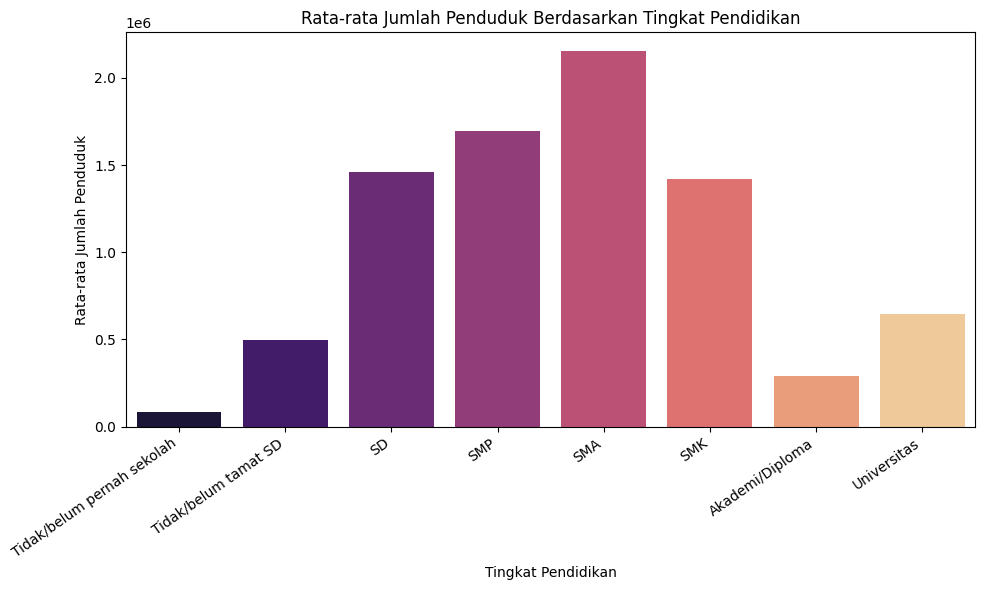

In [8]:

plt.figure(figsize=(10, 6))
sns.barplot(data=mean_education_df,
    x="Tingkat Pendidikan",
    hue="Tingkat Pendidikan",
    y="Rata-rata Jumlah Penduduk",
    palette="magma"
)
plt.xticks(rotation=35, ha="right")
plt.title("Rata-rata Jumlah Penduduk Berdasarkan Tingkat Pendidikan")
plt.ylabel("Rata-rata Jumlah Penduduk")
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('Periode')['Total'].mean().sort_values()

Periode
2019     7001610.0
2017     7005262.0
2018     7018421.0
2016     7027973.5
2014     7195987.0
2013     7325914.0
2015     7507794.5
2012     7551348.5
2020     8346620.0
2022     8418005.0
2010     8456134.5
2011     8530637.0
2021     8924030.0
2009     9110790.5
2008     9411052.5
2007    10279529.5
2006    11018346.5
Name: Total, dtype: float64

In [ ]:
total_pengangguran_per_tahun = df.groupby('Periode')['Total'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.lineplot(data=total_pengangguran_per_tahun)
plt.plot(total_pengangguran_per_tahun.index, total_pengangguran_per_tahun.values)
plt.xlabel("Periode")
plt.ylabel("Total Pengangguran")
plt.title("Total Pengangguran Berdasarkan Periode")